In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
torch.set_float32_matmul_precision('high')


In [ ]:
import h5py
import os

# --- 请将路径确认为您的H5文件 ---
SEGMENTATION_H5 = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_contours_global.tiff.h5"

print(f"Inspecting file: {SEGMENTATION_H5}\n")

def print_hdf5_structure(name, obj):
    """递归打印HDF5文件结构"""
    print(name, f"({type(obj).__name__})")

try:
    with h5py.File(SEGMENTATION_H5, 'r') as f:
        print("--- File Structure ---")
        f.visititems(print_hdf5_structure)
        print("--------------------")
except FileNotFoundError:
    print(f"Error: File not found at {SEGMENTATION_H5}")
except Exception as e:
    print(f"An error occurred: {e}")

Inspecting file: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_contours_global.tiff.h5

--- File Structure ---
ClassificationNode (Group)
ClassificationNode/metadata (Dataset)
ClassificationNode/nuclei_class_HEX_color (Dataset)
ClassificationNode/nuclei_class_id (Dataset)
ClassificationNode/nuclei_class_name (Dataset)
ClassificationNode/output (Dataset)
SegmentationNode (Group)
SegmentationNode/centroids (Dataset)
SegmentationNode/centroids_global (Dataset)
SegmentationNode/contours (Dataset)
SegmentationNode/contours_global (Dataset)
SegmentationNode/embedding (Dataset)
SegmentationNode/probability (Dataset)
user_annotation (Group)
user_annotation/nuclei_annotations (Dataset)
--------------------


1) Loading nucleus contours and centroids from H5 file…
  > Processing contours with direct 1-to-1 mapping...
  > Loaded 154648 unique nucleus contours.

2) Opening high-resolution image and generating 2 verification patches…
  > Image dimensions: 32674 x 43999 pixels.

--- Generating Patch 1/2 ---
  > Centered on nucleus 138863 at (27378, 33179).
  > Found 61 nuclei in the patch.


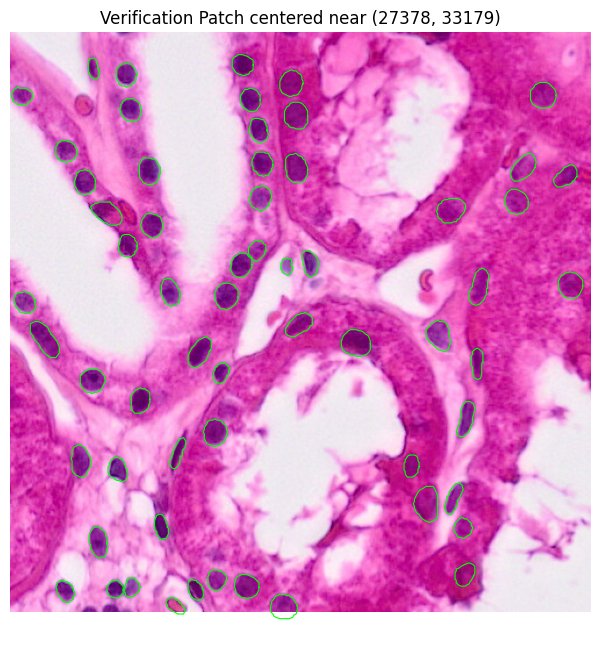


--- Generating Patch 2/2 ---
  > Centered on nucleus 95438 at (4076, 28165).
  > Found 45 nuclei in the patch.


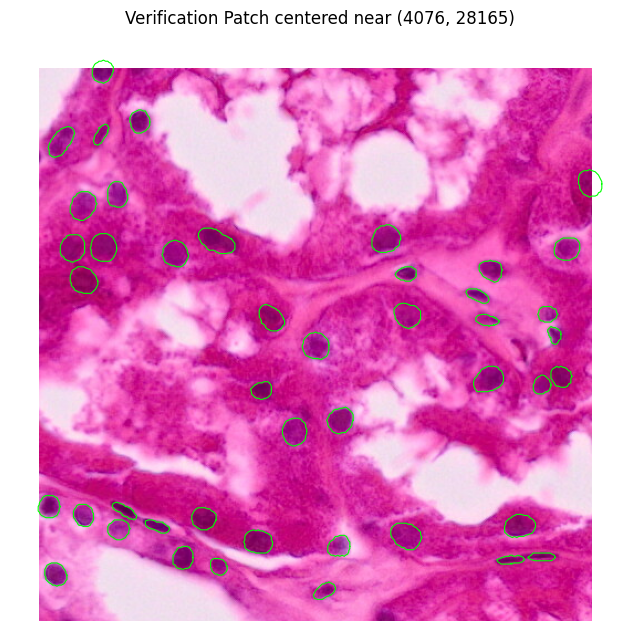


✅ Verification script finished successfully!


In [9]:
#!/usr/bin/env python3
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# 允许PIL打开非常大的图像文件
Image.MAX_IMAGE_PIXELS = None

# ── 0. 配置 ─────────────────────────────────────────────────────────
BASE            = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney"
HE_IMAGE        = os.path.join(BASE, "Visium_HD_Human_Kidney_FFPE_tissue_image.btf")
SEGMENTATION_H5 = os.path.join(BASE, "kidney_contours_global.tiff.h5")
# 输出文件夹不再需要，因为我们直接显示图片
# PLOTS_DIR       = os.path.join(BASE, "plots_kidney_verification")
# os.makedirs(PLOTS_DIR, exist_ok=True)

NUM_PATCHES     = 2  # 生成2张检查图片
PATCH_SIZE      = 500 # 图片大小为 500x500 像素

# ── 1. 加载细胞核分割数据 ──────────────────────────────────────────
print("1) Loading nucleus contours and centroids from H5 file…")
with h5py.File(SEGMENTATION_H5, 'r') as f:
    contours_global = f['SegmentationNode/contours_global'][:]
    centroids_global = f['SegmentationNode/centroids_global'][:]

print("  > Processing contours with direct 1-to-1 mapping...")
num_nuclei = centroids_global.shape[0]
contours_by_id = {i: contours_global[i] for i in range(num_nuclei)}
print(f"  > Loaded {len(contours_by_id)} unique nucleus contours.\n")


# ── 2. 加载高分辨率图像并生成检查图 ────────────────
print(f"2) Opening high-resolution image and generating {NUM_PATCHES} verification patches…")
with Image.open(HE_IMAGE) as img:
    img_width, img_height = img.size
    print(f"  > Image dimensions: {img_width} x {img_height} pixels.")

    for i in range(NUM_PATCHES):
        print(f"\n--- Generating Patch {i+1}/{NUM_PATCHES} ---")
        
        # ✨ 核心修正：先随机选一个细胞核，再以它为中心创建区域 ✨
        # 1. 随机选择一个细胞核的ID
        random_nucleus_id = np.random.randint(0, num_nuclei)
        center_x, center_y = centroids_global[random_nucleus_id]
        
        # 2. 计算以该细胞核为中心的截图区域的左上角坐标
        x_start = int(center_x - PATCH_SIZE / 2)
        y_start = int(center_y - PATCH_SIZE / 2)
        
        # 3. 确保截图区域不会超出图像边界
        x_start = max(0, min(x_start, img_width - PATCH_SIZE))
        y_start = max(0, min(y_start, img_height - PATCH_SIZE))
        
        crop_box = (x_start, y_start, x_start + PATCH_SIZE, y_start + PATCH_SIZE)
        
        # 裁剪图像
        img_patch = img.crop(crop_box)
        
        # 找出所有落在这个新区域内的细胞核
        centroids_in_patch_mask = (
            (centroids_global[:, 0] >= x_start) & (centroids_global[:, 0] < x_start + PATCH_SIZE) &
            (centroids_global[:, 1] >= y_start) & (centroids_global[:, 1] < y_start + PATCH_SIZE)
        )
        nucleus_ids_in_patch = np.where(centroids_in_patch_mask)[0]
        
        print(f"  > Centered on nucleus {random_nucleus_id} at ({int(center_x)}, {int(center_y)}).")
        print(f"  > Found {len(nucleus_ids_in_patch)} nuclei in the patch.")

        # --- 开始绘图 ---
        fig, ax = plt.subplots(figsize=(8, 8)) # 调整显示大小
        ax.imshow(img_patch)
        
        for nuc_id in nucleus_ids_in_patch:
            if nuc_id in contours_by_id:
                contour_points = contours_by_id[nuc_id]
                local_contour_points = contour_points - [x_start, y_start]
                ax.plot(
                    np.append(local_contour_points[:, 0], local_contour_points[0, 0]),
                    np.append(local_contour_points[:, 1], local_contour_points[0, 1]),
                    color='lime',
                    linewidth=0.8
                )

        ax.set_title(f"Verification Patch centered near ({int(center_x)}, {int(center_y)})")
        ax.axis('off')
        
        # ✨ 核心修正：直接显示图片，而不是保存 ✨
        plt.show()

print("\n✅ Verification script finished successfully!")

In [2]:
#!/usr/bin/env python3
"""
Visium HD - 主分析流程：细胞核基因表达浓度计算 (已修正所有错误)

本脚本在成功验证坐标对齐后执行，用于生成最终的细胞核层级的AnnData对象。
"""
import os
import h5py
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import geopandas as gpd
from shapely.geometry import Point, Polygon
from scipy import sparse
from tqdm import tqdm
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=anndata.OldFormatWarning)

# ── 0. 配置 ─────────────────────────────────────────────────────────
BASE          = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney"
BINS_DIR      = os.path.join(BASE, "binned_outputs", "square_002um")
COUNTS_H5     = os.path.join(BINS_DIR, "filtered_feature_bc_matrix.h5")
SPATIAL_PQ    = os.path.join(BINS_DIR, "spatial", "tissue_positions.parquet")
SEGMENTATION_H5 = os.path.join(BASE, "kidney_contours_global.tiff.h5")
OUT_H5AD      = os.path.join(BASE, "kidney_nuclei_expression_concentration.h5ad")

print("--- 主分析流程：细胞核基因表达浓度 ---")
print(f"输入 Counts H5: {COUNTS_H5}")
print(f"输入 Spatial Parquet: {SPATIAL_PQ}")
print(f"输入 Segmentation H5: {SEGMENTATION_H5}")
print(f"输出 AnnData: {OUT_H5AD}")
print("----------------------------------------\n")

# ── 1. 加载 Visium HD Bin 数据 ─────────────────────────────────────
print("1) 加载 2µm bin 的基因计数和空间坐标…")
adata_bins = sc.read_10x_h5(COUNTS_H5)
adata_bins.var_names_make_unique()
coords = pd.read_parquet(SPATIAL_PQ).set_index("barcode")
adata_bins.obs = adata_bins.obs.join(coords[["pxl_col_in_fullres", "pxl_row_in_fullres"]])
print(f"  > 加载了 {adata_bins.shape[0]} 个 bins 和 {adata_bins.shape[1]} 个基因。\n")

# ── 2. 加载细胞核分割数据 ──────────────────
print("2) 加载细胞核轮廓和中心点…")
with h5py.File(SEGMENTATION_H5, 'r') as f:
    contours_global = f['SegmentationNode/contours_global'][:]
    centroids_global = f['SegmentationNode/centroids_global'][:]

print("  > 根据一一对应关系构建细胞核多边形…")
num_nuclei = contours_global.shape[0]
polygons = []
for i in tqdm(range(num_nuclei), desc="    构建多边形"):
    valid_points = contours_global[i][~np.all(contours_global[i] == 0, axis=1)]
    if len(valid_points) >= 3:
        polygons.append(Polygon(valid_points))
    else:
        polygons.append(None)

gdf_nuclei = gpd.GeoDataFrame({
    'nucleus_id': range(num_nuclei),
    'geometry': polygons
}).set_index('nucleus_id')
gdf_nuclei.dropna(inplace=True)
print(f"  > 成功构建了 {len(gdf_nuclei)} 个细胞核多边形。\n")

# ── 3. 空间连接：将 Bins 映射到细胞核 ──────────────────────────────
print("3) 空间连接：将 bins 映射到细胞核…")
gdf_bins = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        x=adata_bins.obs["pxl_col_in_fullres"],
        y=adata_bins.obs["pxl_row_in_fullres"]
    ),
    index=adata_bins.obs.index
)
joined_gdf = gpd.sjoin(gdf_bins, gdf_nuclei, how="inner", predicate="within")

# ── 4. 过滤非唯一映射的 Bins ──────────────────────────────────
print("4) 过滤只落入单个细胞核的 bins…")
barcode_counts = joined_gdf.index.value_counts()
unique_barcodes = barcode_counts[barcode_counts == 1].index
unique_joined_gdf = joined_gdf.loc[unique_barcodes]
print(f"  > 找到 {len(unique_barcodes)} 个唯一映射到细胞核的 bins。\n")

# ── 5. 聚合每个细胞核的基因表达量 (UMI Counts) ──────────────────
print("5) 按细胞核聚合 UMI 计数…")
adata_bins_filtered = adata_bins[unique_barcodes].copy()
adata_bins_filtered.obs['nucleus_id'] = unique_joined_gdf['nucleus_id']

unique_nuc_ids_cat = adata_bins_filtered.obs['nucleus_id'].astype('category')
id_map = {nid: i for i, nid in enumerate(unique_nuc_ids_cat.cat.categories)}
n_nuclei_final = len(id_map)
agg_matrix = sparse.csr_matrix((np.ones(len(unique_nuc_ids_cat)),
                               (unique_nuc_ids_cat.cat.codes, np.arange(adata_bins_filtered.n_obs))),
                               shape=(n_nuclei_final, adata_bins_filtered.n_obs))
aggregated_counts = agg_matrix @ adata_bins_filtered.X
print("  > UMI 聚合完成。\n")

# ── 6. 计算基因表达浓度并创建最终 AnnData 对象 ──────────────────
print("6) 计算基因表达浓度…")
nucleus_areas = adata_bins_filtered.obs['nucleus_id'].value_counts().sort_index()
sorted_nuc_ids = unique_nuc_ids_cat.cat.categories
nucleus_areas = nucleus_areas.loc[sorted_nuc_ids]

concentration_matrix = aggregated_counts.multiply(1 / nucleus_areas.values[:, np.newaxis])

# ✨ 最终修正: 将稀疏矩阵转换为 anndata 支持的 CSR 格式
concentration_matrix_csr = concentration_matrix.tocsr()

obs_df = pd.DataFrame(index=sorted_nuc_ids)
obs_df['num_bins'] = nucleus_areas
final_centroids = pd.DataFrame(centroids_global[sorted_nuc_ids],
                               index=sorted_nuc_ids,
                               columns=['x_centroid', 'y_centroid'])
obs_df = obs_df.join(final_centroids)

nuc_adata = anndata.AnnData(
    X=concentration_matrix_csr, # 使用转换后的矩阵
    obs=obs_df,
    var=adata_bins.var.copy()
)
nuc_adata.obs.index.name = 'nucleus_id'
print("  > 最终的 AnnData 对象已创建。\n")
print(nuc_adata)

# ── 7. 保存结果 ──────────────────────────────────────────────────
print(f"7) 保存最终的细胞核 AnnData 对象到:\n   {OUT_H5AD}")
nuc_adata.write_h5ad(OUT_H5AD, compression="gzip")
print("\n✅ 主分析流程成功完成！")

--- 主分析流程：细胞核基因表达浓度 ---
输入 Counts H5: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/binned_outputs/square_002um/filtered_feature_bc_matrix.h5
输入 Spatial Parquet: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/binned_outputs/square_002um/spatial/tissue_positions.parquet
输入 Segmentation H5: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_contours_global.tiff.h5
输出 AnnData: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_nuclei_expression_concentration.h5ad
----------------------------------------

1) 加载 2µm bin 的基因计数和空间坐标…
  > 加载了 10651345 个 bins 和 18132 个基因。

2) 加载细胞核轮廓和中心点…
  > 根据一一对应关系构建细胞核多边形…


    构建多边形: 100%|██████████| 154648/154648 [00:03<00:00, 47233.38it/s]


  > 成功构建了 154648 个细胞核多边形。

3) 空间连接：将 bins 映射到细胞核…
4) 过滤只落入单个细胞核的 bins…
  > 找到 991231 个唯一映射到细胞核的 bins。

5) 按细胞核聚合 UMI 计数…
  > UMI 聚合完成。

6) 计算基因表达浓度…


/project/zhihuanglab/xuyinuo/plip_model_updated/plip/lib64/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


  > 最终的 AnnData 对象已创建。

AnnData object with n_obs × n_vars = 152155 × 18132
    obs: 'num_bins', 'x_centroid', 'y_centroid'
    var: 'gene_ids', 'feature_types', 'genome'
7) 保存最终的细胞核 AnnData 对象到:
   /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_nuclei_expression_concentration.h5ad

✅ 主分析流程成功完成！


--- 1. 加载细胞核表达数据 ---


AnnData object with n_obs × n_vars = 152155 × 18132
    obs: 'num_bins', 'x_centroid', 'y_centroid'
    var: 'gene_ids', 'feature_types', 'genome'

--- 2. 数据预处理和降维 ---
  > PCA 降维完成，结果保存在 adata.obsm['X_pca']

--- 3. 构建空间邻接网络 ---
  > 空间邻接图构建完成。

--- 4. 开始循环聚类和注释 ---

==================== 正在处理 K = 5 的情况 ====================
[5-1] 邻里聚合...


  0%|          | 0/4 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[5-2] 执行聚类 (n_clusters=5)...


`Trainer.fit` stopped: `max_epochs=9` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[5-3] 寻找并打印每个Cluster的Top 10 Marker基因...
  Cluster 0 (K=5) Top Markers: MT-CO3, MT-CYB, GPX3, MT-ND4L, MT-CO2, MT-ATP6, MT-CO1, MT-ND4, MT-ND2, PAH
  Cluster 1 (K=5) Top Markers: IGKC, TMSB4X, IGHG1, CD74, C7, ACTB, FOS, A2M, VIM, IGHM
  Cluster 2 (K=5) Top Markers: TMSB4X, IGFBP5, SYNE1, EPAS1, NPHS2, PODXL, A2M, VIM, CD74, PTGDS
  Cluster 3 (K=5) Top Markers: DEFB1, SLC12A3, ATP1B1, RNPC3, MAL, CA12, MT-CO3, MT-CO1, SLC4A9, UMOD
  Cluster 4 (K=5) Top Markers: FOS, C7, A2M, DEFB1, SELENOP, EPAS1, CD74, SLC12A3, ENG, IGFBP5
[5-4] 请根据上面的Marker基因列表，为 K=5 的 5 个Cluster命名。
  > 域名已成功保存到 adata.obs['domain_k5']
[5-5] 生成 K=5 的聚类可视化结果...


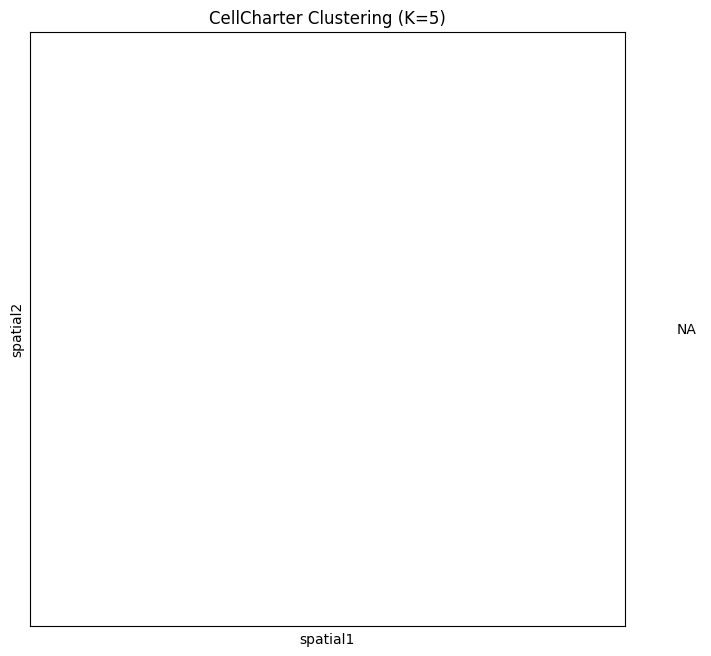


==================== 正在处理 K = 6 的情况 ====================
[6-1] 邻里聚合...


  0%|          | 0/4 [00:00<?, ?it/s]

[6-2] 执行聚类 (n_clusters=6)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=11` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEV

Training: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[6-3] 寻找并打印每个Cluster的Top 10 Marker基因...
  Cluster 0 (K=6) Top Markers: IGKC, TMSB4X, IGHG1, C7, CD74, FOS, ACTB, A2M, VIM, SLC12A3
  Cluster 1 (K=6) Top Markers: DEFB1, UMOD, SLC12A1, SLC4A9, SLC26A7, MAL, ACTB, SLC4A1, ATP1B1, SLC8A1
  Cluster 2 (K=6) Top Markers: SLC12A3, DEFB1, RNPC3, MT-CO3, ATP1B1, MT-CO1, MT-ATP6, CA12, SPP1, MT-CYB
  Cluster 3 (K=6) Top Markers: FOS, C7, CCN2, ENG, A2M, VIM, EGR1, TPM1, EPAS1, CCN1
  Cluster 4 (K=6) Top Markers: MT-CO3, MT-CYB, GPX3, MT-ND4L, MT-CO2, MT-ATP6, MT-CO1, MT-ND4, MT-ND2, MT-ND3
  Cluster 5 (K=6) Top Markers: TMSB4X, SYNE1, NPHS2, IGFBP5, PODXL, EPAS1, A2M, VIM, PTGDS, PLA2R1
[6-4] 请根据上面的Marker基因列表，为 K=6 的 6 个Cluster命名。
  > 域名已成功保存到 adata.obs['domain_k6']
[6-5] 生成 K=6 的聚类可视化结果...


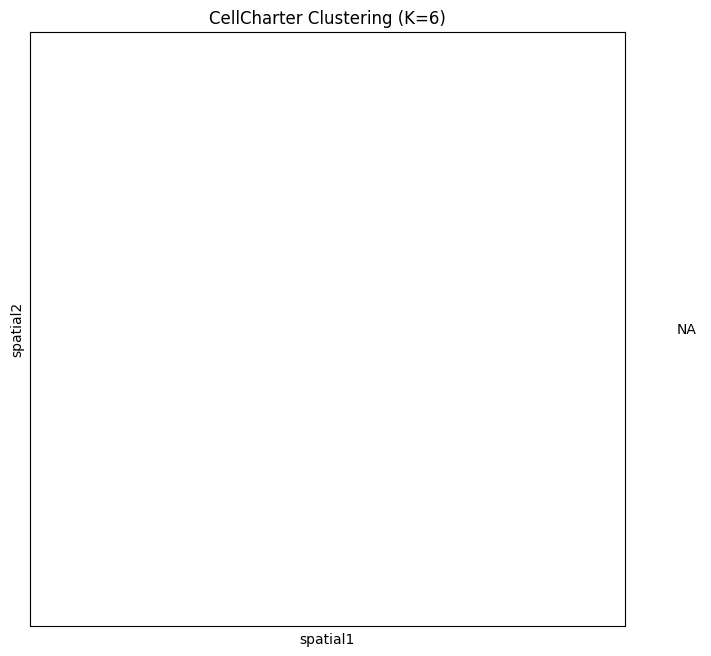


==================== 正在处理 K = 7 的情况 ====================
[7-1] 邻里聚合...


  0%|          | 0/4 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[7-2] 执行聚类 (n_clusters=7)...


`Trainer.fit` stopped: `max_epochs=13` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[7-3] 寻找并打印每个Cluster的Top 10 Marker基因...
  Cluster 0 (K=7) Top Markers: UMOD, SLC12A1, FOS, DEFB1, MAL, ATP1B1, CA12, WSB1, SLC4A9, CDH16
  Cluster 1 (K=7) Top Markers: IGKC, TMSB4X, IGHG1, CD74, C7, ACTB, A2M, FOS, VIM, IGHM
  Cluster 2 (K=7) Top Markers: TMSB4X, SYNE1, NPHS2, PODXL, IGFBP5, PTGDS, CLIC5, PLA2R1, EPAS1, MME
  Cluster 3 (K=7) Top Markers: C7, A2M, TPM1, EPAS1, ENG, CD74, VIM, CXCL12, GPX3, FBLN5
  Cluster 4 (K=7) Top Markers: MT-CO3, MT-CYB, GPX3, MT-ND4L, MT-CO2, MT-ATP6, MT-CO1, MT-ND4, MT-ND2, PAH
  Cluster 5 (K=7) Top Markers: SLC12A3, DEFB1, RNPC3, ATP1B1, MT-CO3, MAL, CA12, MT-CO1, SLC4A9, SLC8A1
  Cluster 6 (K=7) Top Markers: FOS, A2M, CCN2, C7, SYNE1, EPAS1, DEFB1, SELENOP, ENG, IGFBP7
[7-4] 请根据上面的Marker基因列表，为 K=7 的 7 个Cluster命名。
  > 域名已成功保存到 adata.obs['domain_k7']
[7-5] 生成 K=7 的聚类可视化结果...


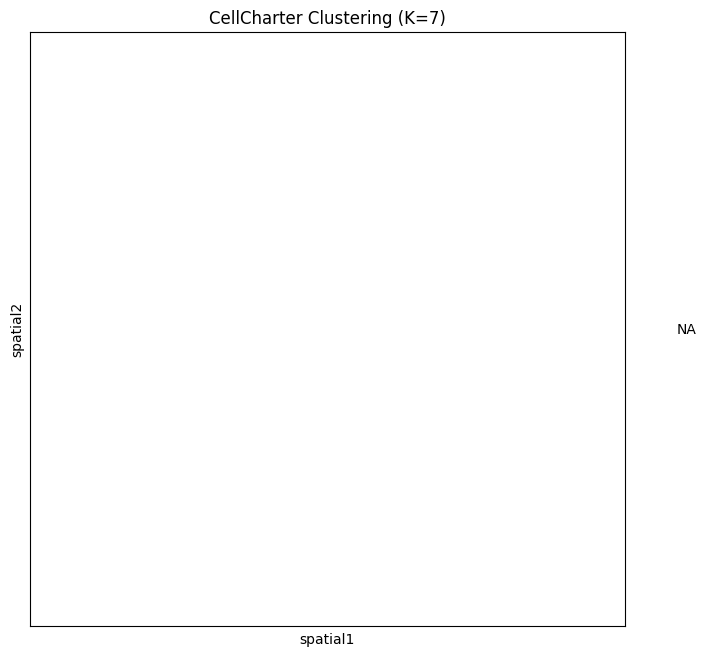


==================== 正在处理 K = 8 的情况 ====================
[8-1] 邻里聚合...


  0%|          | 0/4 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[8-2] 执行聚类 (n_clusters=8)...


`Trainer.fit` stopped: `max_epochs=15` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[8-3] 寻找并打印每个Cluster的Top 10 Marker基因...
  Cluster 0 (K=8) Top Markers: C7, A2M, TPM1, ENG, FOS, EPAS1, CD74, VIM, GPX3, CCN2
  Cluster 1 (K=8) Top Markers: IGKC, TMSB4X, IGHG1, CD74, C7, ACTB, VIM, FOS, A2M, IGHM
  Cluster 2 (K=8) Top Markers: FOS, A2M, DEFB1, CCN2, C7, SLC12A1, UMOD, SLC12A3, TMSB4X, IGFBP7
  Cluster 3 (K=8) Top Markers: SLC12A3, DEFB1, RNPC3, ATP1B1, CA12, SPP1, EGF, MAL, MT-CO3, TMEM52B
  Cluster 4 (K=8) Top Markers: MT-CO3, MT-CYB, GPX3, MT-ND4L, MT-CO2, MT-ATP6, MT-CO1, MT-ND4, MT-ND2, MT-ND3
  Cluster 5 (K=8) Top Markers: DEFB1, UMOD, SLC12A1, SLC4A9, MAL, SLC26A7, ATP1B1, ACTB, SLC8A1, SLC4A1
  Cluster 6 (K=8) Top Markers: IGKC, SLC4A9, FOS, C7, MAL, SLC12A3, DEFB1, CA12, SLC4A1, ATP1B1
  Cluster 7 (K=8) Top Markers: TMSB4X, NPHS2, SYNE1, PODXL, IGFBP5, PTGDS, PLA2R1, CLIC5, EPAS1, MME
[8-4] 请根据上面的Marker基因列表，为 K=8 的 8 个Cluster命名。
  > 域名已成功保存到 adata.obs['domain_k8']
[8-5] 生成 K=8 的聚类可视化结果...


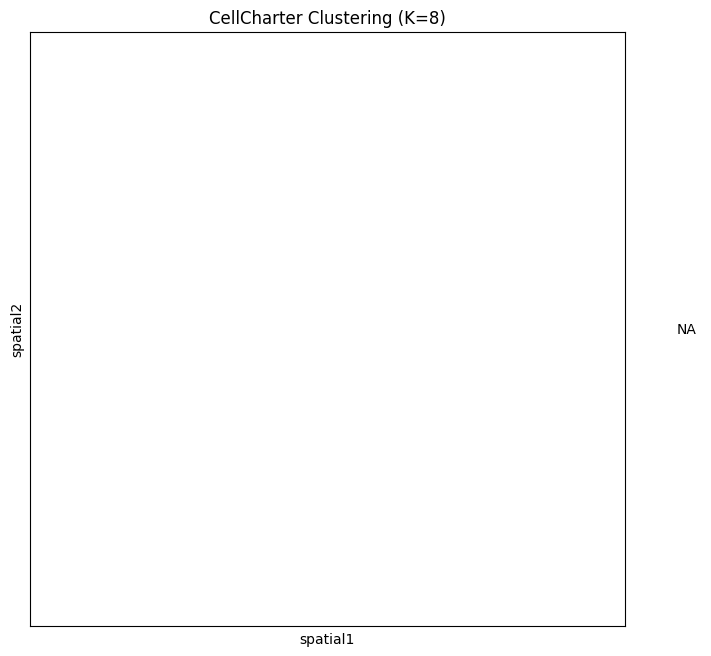


==================== 正在处理 K = 9 的情况 ====================
[9-1] 邻里聚合...


  0%|          | 0/4 [00:00<?, ?it/s]

[9-2] 执行聚类 (n_clusters=9)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=17` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEV

Training: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[9-3] 寻找并打印每个Cluster的Top 10 Marker基因...
  Cluster 0 (K=9) Top Markers: TMSB4X, NPHS2, SYNE1, PODXL, IGFBP5, PTGDS, PLA2R1, EPAS1, CLIC5, MME
  Cluster 1 (K=9) Top Markers: C7, CD74, VIM, MGP, TAGLN, GPX3, DCN, FBLN5, SELENOP, SPARC
  Cluster 2 (K=9) Top Markers: MT-CO3, MT-CYB, GPX3, MT-ND4L, MT-CO2, MT-ATP6, MT-CO1, MT-ND4, MT-ND2, MT-ND3
  Cluster 3 (K=9) Top Markers: DEFB1, UMOD, SLC12A1, SLC4A9, SLC26A7, MAL, ACTB, MT-CO3, ATP1B1, CA12
  Cluster 4 (K=9) Top Markers: SLC12A3, DEFB1, RNPC3, ATP1B1, MT-CO3, CA12, MAL, SPP1, EGF, TMEM52B
  Cluster 5 (K=9) Top Markers: A2M, TPM1, FOS, ENG, C7, EPAS1, CCN2, CCN1, RIPOR3, ACTB
  Cluster 6 (K=9) Top Markers: IGKC, TMSB4X, IGHG1, CD74, C7, ACTB, FOS, A2M, IGHM, VIM
  Cluster 7 (K=9) Top Markers: IGKC, SLC4A9, FOS, MAL, SLC12A3, C7, IGFBP7, DEFB1, SLC26A7, TPM1
  Cluster 8 (K=9) Top Markers: FOS, DEFB1, SLC12A3, A2M, UMOD, SLC12A1, CCN2, RNPC3, IGFBP7, TMSB4X
[9-4] 请根据上面的Marker基因列表，为 K=9 的 9 个Cluster命名。
  > 域名已成功保存到 adata.obs['domain_k9']
[9

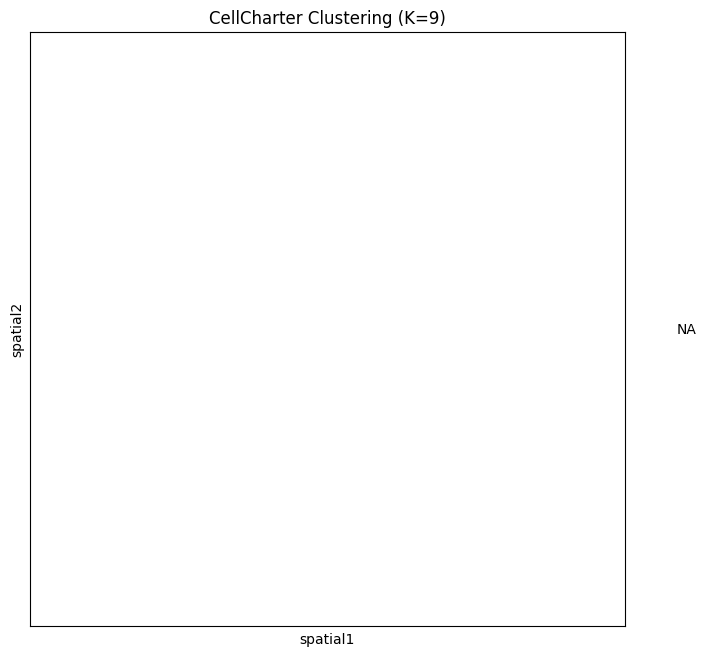


==================== 正在处理 K = 10 的情况 ====================
[10-1] 邻里聚合...


  0%|          | 0/4 [00:00<?, ?it/s]

[10-2] 执行聚类 (n_clusters=10)...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=19` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEV

Training: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[10-3] 寻找并打印每个Cluster的Top 10 Marker基因...
  Cluster 0 (K=10) Top Markers: EPAS1, ENG, TPM1, C7, IGFBP5, A2M, CCN2, CD74, GPX3, EGFL7
  Cluster 1 (K=10) Top Markers: SLC12A3, DEFB1, RNPC3, ATP1B1, MAL, SLC4A9, CA12, UMOD, EPAS1, IGFBP5
  Cluster 2 (K=10) Top Markers: TMSB4X, NPHS2, SYNE1, PODXL, IGFBP5, PTGDS, PLA2R1, CLIC5, EPAS1, MME
  Cluster 3 (K=10) Top Markers: IGKC, TMSB4X, CD74, ACTB, TRAC, C7, TRBC2, IGHM, CORO1A, TMSB10
  Cluster 4 (K=10) Top Markers: IGKC, IGHG1, TMSB4X, FOS, VIM, C7, CD74, ACTB, CCN2, A2M
  Cluster 5 (K=10) Top Markers: MT-CO3, MT-CYB, GPX3, MT-ND4L, MT-CO2, MT-CO1, MT-ATP6, MT-ND4, MT-ND2, MT-ND3
  Cluster 6 (K=10) Top Markers: UMOD, SLC12A1, DEFB1, FOS, SLC4A9, MAL, ATP1B1, CA12, SLC26A7, WSB1
  Cluster 7 (K=10) Top Markers: C7, A2M, GPX3, CD74, VIM, SELENOP, ACTB, FBLN5, MGP, TAGLN
  Cluster 8 (K=10) Top Markers: SLC12A3, DEFB1, RNPC3, ATP1B1, MAL, MT-CO3, CA12, SLC8A1, MT-CO1, PTGER3
  Cluster 9 (K=10) Top Markers: FOS, C7, A2M, CCN2, TMSB4X, EPAS1, ACTB,

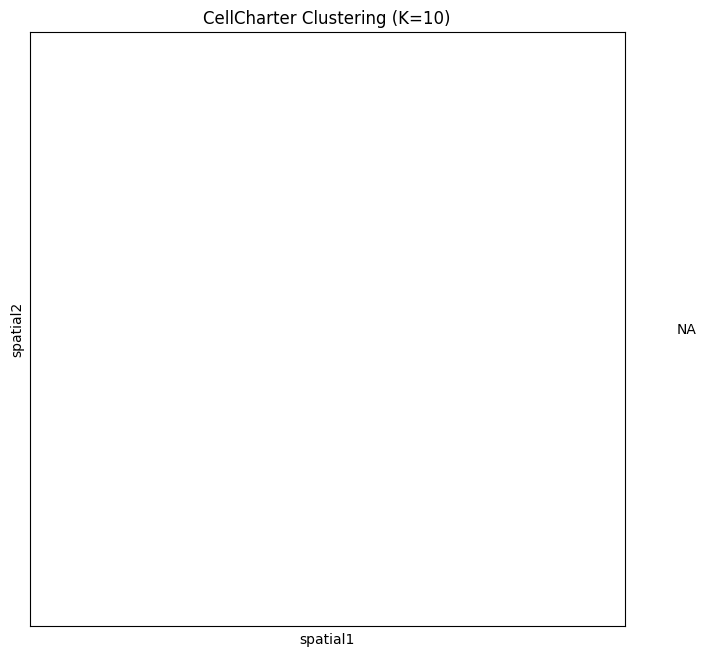



==================== 所有聚类已完成 ====================
最终的AnnData对象包含以下聚类结果:
['cluster_k5', 'domain_k5', 'cluster_k6', 'domain_k6', 'cluster_k7', 'domain_k7', 'cluster_k8', 'domain_k8', 'cluster_k9', 'domain_k9', 'cluster_k10', 'domain_k10']

--- 5. 保存包含所有注释的最终结果到 ---
   /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results.h5ad

✅ 分析流程成功完成！


In [8]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# --- 0. 配置 ---
adata_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_nuclei_expression_concentration.h5ad"
output_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results.h5ad"
CLUSTERS_TO_RUN = [5, 6, 7, 8, 9, 10]

# --- 1. 数据加载和预处理 ---
print("--- 1. 加载细胞核表达数据 ---")
adata = ad.read_h5ad(adata_path)
print(adata)

adata.obsm['spatial'] = adata.obs[['x_centroid', 'y_centroid']].values

# ✨ 最终修正: 为squidpy的绘图函数创建一个必需的占位符
adata.uns['spatial'] = {'kidney_sample': {}}


print("\n--- 2. 数据预处理和降维 ---")
adata.layers["counts"] = adata.X.copy()
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat', layer='counts')
adata.raw = adata

sc.pp.pca(adata, n_comps=30, use_highly_variable=True)
print("  > PCA 降维完成，结果保存在 adata.obsm['X_pca']\n")


# --- 3. 构建空间邻接网络 ---
print("--- 3. 构建空间邻接网络 ---")
sq.gr.spatial_neighbors(adata, coord_type='generic', delaunay=True, spatial_key='spatial')
print("  > 空间邻接图构建完成。\n")

# --- 4. 循环聚类、寻找Marker并进行手动注释 ---
print("--- 4. 开始循环聚类和注释 ---")
for k in CLUSTERS_TO_RUN:
    print(f"\n==================== 正在处理 K = {k} 的情况 ====================")

    print(f"[{k}-1] 邻里聚合...")
    cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_pca', out_key='X_cellcharter')

    print(f"[{k}-2] 执行聚类 (n_clusters={k})...")
    clusterer = cc.tl.Cluster(n_clusters=k, random_state=42)
    cluster_key = f'cluster_k{k}'

    clusterer.fit(adata, use_rep='X_cellcharter')
    adata.obs[cluster_key] = clusterer.predict(adata, use_rep='X_cellcharter')

    adata.obs[cluster_key] = adata.obs[cluster_key].astype('category')

    print(f"[{k}-3] 寻找并打印每个Cluster的Top 10 Marker基因...")
    sc.tl.rank_genes_groups(adata, groupby=cluster_key, method='wilcoxon', use_raw=False)

    marker_df = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
    for cluster_id in marker_df.columns:
        top_markers = marker_df[cluster_id].head(10).tolist()
        print(f"  Cluster {cluster_id} (K={k}) Top Markers: {', '.join(top_markers)}")

    print(f"[{k}-4] 请根据上面的Marker基因列表，为 K={k} 的 {k} 个Cluster命名。")

    domain_names = []
    while len(domain_names) != k:
        user_input = input(f"请输入 {k} 个域名，用逗号分隔 (例如: Proximal_Tubule,Glomerulus,...): ")
        domain_names = [name.strip() for name in user_input.split(',')]
        if len(domain_names) != k:
            print(f"  输入错误！您输入了 {len(domain_names)} 个名字，但需要 {k} 个。请重试。")

    domain_map = {str(i): domain_names[i] for i in range(k)}
    domain_key = f'domain_k{k}'
    adata.obs[domain_key] = adata.obs[cluster_key].map(domain_map).astype('category')
    print(f"  > 域名已成功保存到 adata.obs['{domain_key}']")

    print(f"[{k}-5] 生成 K={k} 的聚类可视化结果...")
    sq.pl.spatial_scatter(
        adata,
        color=[domain_key],
        size=10,
        img=None,
        figsize=(7,7),
        title=f'CellCharter Clustering (K={k})'
    )
    plt.show()

print("\n\n==================== 所有聚类已完成 ====================")
print("最终的AnnData对象包含以下聚类结果:")
print(adata.obs.columns[adata.obs.columns.str.contains('cluster_|domain_')].tolist())

# --- 5. 保存最终结果 ---
print(f"\n--- 5. 保存包含所有注释的最终结果到 ---")
print(f"   {output_path}")
adata.write_h5ad(output_path, compression="gzip")

print("\n✅ 分析流程成功完成！")

In [10]:
import h5py

# 您想查看的文件路径
file_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results.h5ad"

def print_hdf5_structure(name, obj):
    """递归打印HDF5文件结构"""
    print(name)

with h5py.File(file_path, 'r') as f:
    print(f"--- 文件 '{file_path}' 的结构 ---")
    f.visititems(print_hdf5_structure)
    print("--------------------")

--- 文件 '/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results.h5ad' 的结构 ---
X
X/data
X/indices
X/indptr
layers
layers/counts
layers/counts/data
layers/counts/indices
layers/counts/indptr


obs
obs/cluster_k10
obs/cluster_k10/categories
obs/cluster_k10/codes
obs/cluster_k5
obs/cluster_k5/categories
obs/cluster_k5/codes
obs/cluster_k6
obs/cluster_k6/categories
obs/cluster_k6/codes
obs/cluster_k7
obs/cluster_k7/categories
obs/cluster_k7/codes
obs/cluster_k8
obs/cluster_k8/categories
obs/cluster_k8/codes
obs/cluster_k9
obs/cluster_k9/categories
obs/cluster_k9/codes
obs/domain_k10
obs/domain_k10/categories
obs/domain_k10/codes
obs/domain_k5
obs/domain_k5/categories
obs/domain_k5/codes
obs/domain_k6
obs/domain_k6/categories
obs/domain_k6/codes
obs/domain_k7
obs/domain_k7/categories
obs/domain_k7/codes
obs/domain_k8
obs/domain_k8/categories
obs/domain_k8/codes
obs/domain_k9
obs/domain_k9/categories
obs/domain_k9/codes
obs/nucleus_id
obs/num_bins
obs/x_centroid
obs/y_centroid
obsm
obsm/X_cellcharter
obsm/X_pca
obsm/spatial
obsp
obsp/spatial_connectivities
obsp/spatial_connectivities/data
obsp/spatial_connectivities/indices
obsp/spatial_connectivities/indptr
obsp/spatial_distance

In [ ]:
import anndata as ad

# 定义输入和输出文件路径
input_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results.h5ad"
output_path_corrected = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results_corrected.h5ad"

print(f"1. 正在加载文件: {input_path}")
adata = ad.read_h5ad(input_path)

# 这是我们之前所有交互中确定的域名列表
all_domain_names = {
    5: ['Proximal_Tubule','Immune_Cells','Glomerulus','Distal_Tubule','Vascular_Stromal'],
    6: ['Immune_Cells','Thick_Ascending_Limb','Distal_Tubule','Vascular_Stromal','Proximal_Tubule','Glomerulus'],
    7: ['Thick_Ascending_Limb','Immune_Cells','Glomerulus','Vascular_Stromal','Proximal_Tubule','Distal_Tubule','Interstitium'],
    8: ['Vascular_Stromal','Immune_Cells','Interstitium','Distal_Tubule','Proximal_Tubule','Thick_Ascending_Limb','Infiltrated_Tubule','Glomerulus'],
    9: ['Glomerulus','Stroma_Fibroblast','Proximal_Tubule','Thick_Ascending_Limb','Distal_Tubule','Vascular_Endothelium','Immune_Cells','Infiltrated_Tubule','Interstitium'],
    10: ['Vascular_Endothelium','Distal_Tubule_1','Glomerulus','T_Cells','B_Cells','Proximal_Tubule','Thick_Ascending_Limb','Stroma_Fibroblast','Distal_Tubule_2','Interstitium']
}

print("\n2. 开始修正domain列的NaN值...")
# 循环处理 k=5 到 k=10 的所有结果
for k, domain_names in all_domain_names.items():
    cluster_key = f'cluster_k{k}'
    domain_key = f'domain_k{k}'
    
    # ✨ 核心修正: 创建字典时，使用整数作为键，而不是字符串 ✨
    domain_map = {i: domain_names[i] for i in range(k)}
    
    # 重新进行映射
    # 我们需要先将categorical类型转为整数才能进行map
    adata.obs[domain_key] = adata.obs[cluster_key].astype(int).map(domain_map).astype('category')
    
    print(f"  - 已成功修正 '{domain_key}' 列。")

print("\n3. 修正完成！检查K=8的结果：")
print(adata.obs['domain_k8'].value_counts())

print(f"\n4. 正在保存修正后的文件到: {output_path_corrected}")
adata.write_h5ad(output_path_corrected)

print("\n✅ 修正流程成功完成！新文件已保存。")

1. 正在加载文件: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results.h5ad

2. 开始修正domain列的NaN值...
  - 已成功修正 'domain_k5' 列。
  - 已成功修正 'domain_k6' 列。
  - 已成功修正 'domain_k7' 列。
  - 已成功修正 'domain_k8' 列。
  - 已成功修正 'domain_k9' 列。
  - 已成功修正 'domain_k10' 列。

3. 修正完成！检查K=8的结果：
domain_k8
Proximal_Tubule         49546
Vascular_Stromal        21437
Thick_Ascending_Limb    19563
Glomerulus              18488
Distal_Tubule           14347
Interstitium            11074
Immune_Cells            10594
Infiltrated_Tubule       7106
Name: count, dtype: int64

4. 正在保存修正后的文件到: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results_corrected.h5ad

✅ 修正流程成功完成！新文件已保存。


In [ ]:
import anndata as ad

# 加载文件
file_path = "kidney_cellcharter_results_corrected.h5ad"
adata = ad.read_h5ad(file_path)

# 打印 AnnData 对象的摘要信息
print(adata)

AnnData object with n_obs × n_vars = 152155 × 18132
    obs: 'num_bins', 'x_centroid', 'y_centroid', 'cluster_k5', 'domain_k5', 'cluster_k6', 'domain_k6', 'cluster_k7', 'domain_k7', 'cluster_k8', 'domain_k8', 'cluster_k9', 'domain_k9', 'cluster_k10', 'domain_k10'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: '_cellcharter', 'domain_k10_colors', 'domain_k5_colors', 'domain_k6_colors', 'domain_k7_colors', 'domain_k8_colors', 'domain_k9_colors', 'hvg', 'log1p', 'pca', 'rank_genes_groups', 'spatial', 'spatial_neighbors'
    obsm: 'X_cellcharter', 'X_pca', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'


In [13]:
import anndata as ad

# Define the path to your final, corrected AnnData file
file_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_cellcharter_results_corrected.h5ad"

# Load the AnnData object
adata = ad.read_h5ad(file_path)

# Select the specific columns you want to see
# 'x_centroid' and 'y_centroid' for coordinates
# 'domain_k5' for the names from the K=5 clustering
columns_to_show = ['x_centroid', 'y_centroid', 'domain_k5']

# Get the first 5 rows of these selected columns and print the result
first_five_entries = adata.obs[columns_to_show].head(5)

print("Displaying the coordinates and domain names for the first 5 nuclei (K=5 result):")
print(first_five_entries)

Displaying the coordinates and domain names for the first 5 nuclei (K=5 result):
            x_centroid  y_centroid        domain_k5
nucleus_id                                         
0                 3816       13211  Proximal_Tubule
1                 3390       13983  Proximal_Tubule
2                 3842       12973    Distal_Tubule
3                 3718       13517    Distal_Tubule
5                 3582       13959    Distal_Tubule


In [5]:
#!/usr/bin/env python3
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

Image.MAX_IMAGE_PIXELS = None

# ── 0. CONFIGURATION ─────────────────────────────────────────────────────────
BASE            = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney"
HE_IMAGE        = os.path.join(BASE, "Visium_HD_Human_Kidney_FFPE_tissue_image.btf")
SEGMENTATION_H5 = os.path.join(BASE, "kidney_contours_global.tiff.h5")
PLOTS_DIR       = os.path.join(BASE, "plots_kidney_verification")
os.makedirs(PLOTS_DIR, exist_ok=True)

NUM_PATCHES     = 2
PATCH_SIZE      = 500

# ── 1. 加载细胞核分割数据 ──────────────────────────────────────────
print("1) Loading nucleus contours and centroids from H5 file…")
with h5py.File(SEGMENTATION_H5, 'r') as f:
    # Corrected paths based on your H5 structure
    contours_global = f['SegmentationNode/contours_global'][:]
    centroids_global = f['SegmentationNode/centroids_global'][:]
    
    ## TODO: Recreate the nucleus ID mapping. This is the part that will
    ##       be determined by the output of the shape inspection script.
    ##       The code below is a placeholder for the logic we will add.
    
    # Placeholder: Assuming a simple structure for now.
    # We will replace this with the correct logic.
    print("  > WARNING: Using placeholder logic for nucleus ID mapping.")
    num_nuclei = centroids_global.shape[0]
    
    # This is an educated guess: that the 'contours' dataset holds the indices.
    if 'SegmentationNode/contours' in f:
        contour_indices = f['SegmentationNode/contours'][:] # e.g., shape (num_nuclei, 2)
        contour_nuc_ids = np.zeros(len(contours_global), dtype=int)
        print("  > Reconstructing nucleus IDs from index dataset...")
        for i in tqdm(range(num_nuclei)):
            start_index = contour_indices[i, 0]
            num_points = contour_indices[i, 1]
            contour_nuc_ids[start_index : start_index + num_points] = i
    else:
        raise ValueError("Cannot determine how to group contours. 'SegmentationNode/contours' missing.")

print("  > Grouping contour points by nucleus ID…")
contour_df = pd.DataFrame(contours_global, columns=['x', 'y'])
contour_df['nucleus_id'] = contour_nuc_ids

contours_by_id = {
    nucleus_id: group[['x', 'y']].values 
    for nucleus_id, group in tqdm(contour_df.groupby('nucleus_id'), desc="    Processing contours")
}
print(f"  > Loaded {len(contours_by_id)} unique nucleus contours.\n")


# ── 2. 加载高分辨率图像并生成检查图 (This part remains the same) ────────────────
print(f"2) Opening high-resolution image and generating {NUM_PATCHES} verification patches…")
with Image.open(HE_IMAGE) as img:
    # ... (The rest of the script is unchanged) ...
    img_width, img_height = img.size
    print(f"  > Image dimensions: {img_width} x {img_height} pixels.")

    for i in range(NUM_PATCHES):
        print(f"\n--- Generating Patch {i+1}/{NUM_PATCHES} ---")
        rand_x_start = np.random.randint(0, img_width - PATCH_SIZE)
        rand_y_start = np.random.randint(0, img_height - PATCH_SIZE)
        crop_box = (rand_x_start, rand_y_start, rand_x_start + PATCH_SIZE, rand_y_start + PATCH_SIZE)
        img_patch = img.crop(crop_box)
        
        centroids_in_patch_mask = (
            (centroids_global[:, 0] >= rand_x_start) & (centroids_global[:, 0] < rand_x_start + PATCH_SIZE) &
            (centroids_global[:, 1] >= rand_y_start) & (centroids_global[:, 1] < rand_y_start + PATCH_SIZE)
        )
        nucleus_ids_in_patch = np.where(centroids_in_patch_mask)[0]
        
        print(f"  > Found {len(nucleus_ids_in_patch)} nuclei in patch at ({rand_x_start}, {rand_y_start}).")

        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(img_patch)
        
        for nuc_id in nucleus_ids_in_patch:
            if nuc_id in contours_by_id:
                contour_points = contours_by_id[nuc_id]
                local_contour_points = contour_points - [rand_x_start, rand_y_start]
                ax.plot(
                    np.append(local_contour_points[:, 0], local_contour_points[0, 0]),
                    np.append(local_contour_points[:, 1], local_contour_points[0, 1]),
                    color='lime',
                    linewidth=0.8
                )

        ax.set_title(f"Verification Patch {i+1} at ({rand_x_start}, {rand_y_start})")
        ax.axis('off')
        
        output_path = os.path.join(PLOTS_DIR, f"verification_patch_{i+1}.png")
        plt.savefig(output_path, dpi=150, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        
        print(f"  > Saved verification image to: {output_path}")

print("\n✅ Verification script finished successfully!")

1) Loading nucleus contours and centroids from H5 file…
  > WARNING: Using placeholder logic for nucleus ID mapping.
  > Reconstructing nucleus IDs from index dataset...


  0%|          | 0/154648 [00:00<?, ?it/s]


TypeError: only integer scalar arrays can be converted to a scalar index

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Visium HD Human Kidney FFPE – Pseudo–Single-Cell Nucleus Pipeline (Final Version)

- Uses CSV for nucleus contours to define area.
- Uses a separate CSV for pre-computed nucleus centroids.

Steps:
1) Imports & configuration
2) Load raw binned counts & spatial barcodes
3) Read nucleus contours from CSV and build Polygons
4) Load pre-computed nucleus centroids from CSV
5) Spatial join barcodes to nucleus areas (polygons)
6) Aggregate UMI counts per nucleus
7) Build new AnnData with per-nucleus counts & pre-computed centroids
8) Save outputs: .h5ad, CSV annotations, centroid table
"""
import os
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import geopandas as gpd
from shapely.geometry import Polygon, Point
import anndata
from tqdm.auto import tqdm

# ── 0) CONFIG ───────────────────────────────────────────────────────────────
BASE_DIR = Path(
    "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney"
)
# Binned 2µm count matrix and spatial barcodes (Visium HD output)
BINS_DIR  = BASE_DIR / "binned_outputs" / "square_002um"
COUNTS_H5 = BINS_DIR / "filtered_feature_bc_matrix.h5"
BARCODES_PQ = BINS_DIR / "spatial" / "tissue_positions.parquet"

# 【输入文件】轮廓和质心的 CSV 文件路径
SEG_CONTOURS_CSV = BASE_DIR / "segmented_outputs" / "scaled_contours.csv"
SEG_CENTROIDS_CSV = BASE_DIR / "segmented_outputs" / "scaled_centroids.csv"

# Output files
OUT_H5AD    = BASE_DIR / "kidney_nuclei.h5ad"
OUT_ANN_CSV = BASE_DIR / "kidney_nucleus_annotations.csv"
OUT_COORDS  = BASE_DIR / "kidney_nucleus_centroids.csv"

# Ensure outputs directory exists
BASE_DIR.mkdir(parents=True, exist_ok=True)

# ── 1) Load counts and barcode positions ────────────────────────────────────
print("1) Loading 2µm counts and spatial barcodes…")
# Validate input files
for p in (COUNTS_H5, BARCODES_PQ, SEG_CONTOURS_CSV, SEG_CENTROIDS_CSV):
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# Read raw count matrix
adata = sc.read_10x_h5(str(COUNTS_H5))
adata.var_names_make_unique()
# Load barcode spatial coords (pixel columns/rows in full-res image)
coords = pd.read_parquet(str(BARCODES_PQ)).set_index("barcode")
# Join spatial coords into adata.obs
adata.obs = adata.obs.join(
    coords[["pxl_col_in_fullres", "pxl_row_in_fullres"]],
    how="inner"
)
print(f"   Joined {adata.n_obs} barcodes with spatial coords")

# ── 2) Read nucleus contours from CSV and create GeoDataFrame ──────────────
print("2) Reading nucleus contours from CSV and building polygons…")
contours_df = pd.read_csv(SEG_CONTOURS_CSV)
tqdm.pandas(desc="   Building polygons")
polygons = contours_df.groupby('object_id')[['contour_x', 'contour_y']].progress_apply(
    lambda g: Polygon(g.values)
)
# 创建 GeoDataFrame，用于空间查询
gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
# 将索引 'object_id' 变为 'nucleus_id' 列，用于后续匹配
gdf = gdf.rename_axis("nucleus_id").reset_index()
gdf.geometry = gdf.geometry.buffer(0) # 修复无效的多边形
print(f"   Loaded and built {len(gdf)} segmented nuclei polygons")


# ── 3) Spatial join barcodes → nuclei ──────────────────────────────────────
print("3) Spatially joining barcodes to nucleus areas…")
pts = gpd.GeoDataFrame(
    adata.obs,
    geometry=[Point(xy) for xy in zip(
        adata.obs['pxl_col_in_fullres'],
        adata.obs['pxl_row_in_fullres']
    )],
    crs=gdf.crs
)
joined = gpd.sjoin(
    pts,
    gdf[['nucleus_id', 'geometry']],
    how='inner',
    predicate='within'
)
counts = joined.index.value_counts()
unique_bcs = counts[counts == 1].index
joined = joined.loc[joined.index.isin(unique_bcs)]
adata.obs['nucleus_id'] = -1
adata.obs.loc[joined.index, 'nucleus_id'] = joined['nucleus_id']
adata = adata[adata.obs['nucleus_id'] >= 0].copy()
print(f"   {adata.n_obs} barcodes assigned to nuclei")


# ── 4) Load pre-computed nucleus centroids ─────────────────────────────────
# 【重大修改】此步骤不再计算质心，而是直接从文件加载
print("4) Loading pre-computed nucleus centroids…")

# 从你同事提供的 CSV 文件加载质心
centroids = pd.read_csv(str(SEG_CENTROIDS_CSV))

# 重命名列以匹配后续代码的期望格式 ('nucleus_id', 'x_center', 'y_center')
centroids = centroids.rename(columns={
    'object_id': 'nucleus_id',
    'centroid_x': 'x_center',
    'centroid_y': 'y_center'
})

# 将 'nucleus_id' 设置为索引，以便轻松地与 AnnData 对象连接
centroids = centroids.set_index('nucleus_id')
print(f"   Loaded centroids for {len(centroids)} nuclei")


# ── 5) Aggregate UMIs per nucleus ──────────────────────────────────────────
# 此步骤无需修改，它根据第3步的空间连接结果来聚合 UMI
print("5) Aggregating UMI counts per nucleus…")
groups = adata.obs['nucleus_id'].astype(int).values
n_nuclei = max(groups.max(), centroids.index.max()) + 1 # 确保矩阵足够大
n_genes = adata.X.shape[1]

M = sparse.lil_matrix((n_nuclei, n_genes), dtype=adata.X.dtype)
for idx, nuc in enumerate(tqdm(groups, desc="    Aggregating")):
    M[nuc] += adata.X[idx]
M = M.tocsr()


# ── 6) Build new AnnData with per-nucleus counts & centroids ───────────────
# 此步骤无需修改，它会将第4步加载的质心和第5步聚合的表达矩阵组合起来
print("6) Assembling final AnnData object…")
obs_df = pd.DataFrame(index=pd.Index(np.arange(n_nuclei), name='nucleus_id'))

# 将加载的质心坐标连接到新的 obs DataFrame
obs_df = obs_df.join(centroids, how='left')

nuc_adata = anndata.AnnData(
    X=M,
    obs=obs_df,
    var=adata.var.copy()
)

# 过滤掉那些在轮廓或质心文件中存在，但没有任何 barcode 落入的细胞核
# 这些细胞核的 x_center 会是 NaN
nuc_adata = nuc_adata[nuc_adata.obs['x_center'].notna()].copy()

# 设置 spatial embedding
if 'x_center' in nuc_adata.obs.columns and 'y_center' in nuc_adata.obs.columns:
    nuc_adata.obsm['spatial'] = nuc_adata.obs[['x_center', 'y_center']].values
else:
    print("警告：坐标 'x_center' 或 'y_center' 未能添加到 obs 中。")


# ── 7) Save outputs ─────────────────────────────────────────────────────────
print("7) Saving outputs…")
# 保存 AnnData
nuc_adata.write_h5ad(str(OUT_H5AD))

# 创建注释文件
ann = nuc_adata.obs[['x_center','y_center']].copy()
ann['n_counts'] = np.array(nuc_adata.X.sum(axis=1)).flatten()
ann.to_csv(str(OUT_ANN_CSV))

# 保存质心坐标表（即保存一份我们加载过的文件，格式统一）
centroids.to_csv(str(OUT_COORDS))
print("Pipeline complete: outputs written to disk.")

1) Loading 2µm counts and spatial barcodes…
   Joined 10651345 barcodes with spatial coords
2) Reading nucleus contours from CSV and building polygons…


   Building polygons:   0%|          | 0/154648 [00:00<?, ?it/s]

   Loaded and built 154648 segmented nuclei polygons
3) Spatially joining barcodes to nucleus areas…
   991294 barcodes assigned to nuclei
4) Loading pre-computed nucleus centroids…
   Loaded centroids for 154648 nuclei
5) Aggregating UMI counts per nucleus…


    Aggregating:   0%|          | 0/991294 [00:00<?, ?it/s]

6) Assembling final AnnData object…
7) Saving outputs…


/project/zhihuanglab/xuyinuo/plip_model_updated/plip/lib64/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Pipeline complete: outputs written to disk.


/project/zhihuanglab/xuyinuo/plip_model_updated/plip/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/project/zhihuanglab/xuyinuo/plip_model_updated/plip/lib64/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


1) Loading per-nucleus AnnData…
   ✓ 154648 nuclei × 18132 genes loaded

2) Computing PCA embedding…
   ✓ PCA stored in obsm['X_pca']

3) Building spatial graph…
   ✓ Graph built

4) Aggregating neighbor features for CellCharter…


  0%|          | 0/4 [00:00<?, ?it/s]

   ✓ Features aggregated in obsm['X_cellcharter']

5) Identifying spatial domains via ClusterAutoK…
Iteration 1/5


  0%|          | 0/16 [00:00<?, ?it/s]

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVI

Iteration 5/5


  0%|          | 0/16 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVI

   ✓ Selected 4 domains

6) Visualizing overlay on H&E image…
   ✓ Overlay image saved to /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains/k_domains_overlay.png

7) Saving final outputs…
   - Saved domain mapping to: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains/kidney_domain_mapping.h5
   - Saved final AnnData to: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains/kidney_spatial_domains.h5ad

Done. All analysis files are in: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains


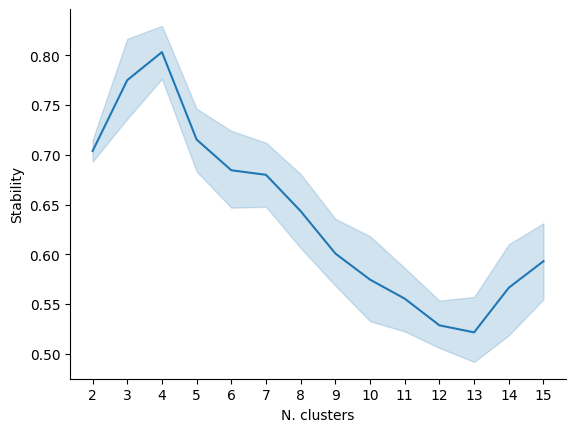

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Kidney Pseudo–Single‑Cell → CellCharter Spatial Domains

This script takes the per-nucleus AnnData object and uses CellCharter
to identify and visualize spatial domains.

Steps:
1) Imports & configuration
2) Load per‑nucleus AnnData
3) PCA embedding
4) Build spatial graph & remove long links
5) Aggregate neighbor features
6) Auto‑select domains via ClusterAutoK
7) Visualize & save H&E overlay
8) Save final results
"""
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import cellcharter as cc
import matplotlib.pyplot as plt
import tifffile
from PIL import Image

# ── 1) CONFIGURATION ─────────────────────────────────────────────────────────
BASE_DIR = Path("/project/zhihuanglab/xuyinuo/plip_model_updated/data/"
                "A_VisiumHD_data_Human/Kidney")
IN_H5AD       = BASE_DIR / "kidney_nuclei.h5ad"
OUTPUT_DIR    = BASE_DIR / "analysis_kidney_domains"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# H&E for overlay
HE_IMAGE      = BASE_DIR / "Visium_HD_Human_Kidney_FFPE_tissue_image.btf"
# Optional: Path to a 3×3 affine matrix for image alignment
ALIGN_CSV     = OUTPUT_DIR / "kidney_he_imagealignment.csv"

# --- Parameters ---
N_PCS         = 30
N_LAYERS      = 3
K_RANGE       = (2, 15)
MAX_RUNS      = 5
CONV_TOL      = 0.001
PCTILE_LONG   = 99
DOWNSAMPLE    = 5
# Microns per pixel for your image, adjust if necessary
MPP           = 0.2125

# --- Output Files ---
OUT_ANNAD     = OUTPUT_DIR / "kidney_spatial_domains.h5ad"
OUT_H5        = OUTPUT_DIR / "kidney_domain_mapping.h5"
OUT_STAB      = OUTPUT_DIR / "k_autok_stability.png"
OUT_OVERLAY   = OUTPUT_DIR / "k_domains_overlay.png"


# ── 2) LOAD PER-NUCLEUS ANNDATA ───────────────────────────────────────────────
print("1) Loading per-nucleus AnnData…")
adata = sc.read_h5ad(str(IN_H5AD))
print(f"   ✓ {adata.n_obs} nuclei × {adata.n_vars} genes loaded\n")

# Ensure spatial coordinates are in the expected .obsm slot
adata.obsm["spatial"] = adata.obs[["x_center", "y_center"]].values


# ── 3) PCA EMBEDDING ─────────────────────────────────────────────────────────
print("2) Computing PCA embedding…")
# Basic preprocessing for PCA
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
ad_pca = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(ad_pca, max_value=10)
sc.tl.pca(ad_pca, n_comps=N_PCS)

# Add the PCA result back to the main AnnData object
adata.obsm["X_pca"] = ad_pca.obsm["X_pca"]
print("   ✓ PCA stored in obsm['X_pca']\n")


# ── 4) BUILD SPATIAL GRAPH ───────────────────────────────────────────────────
print("3) Building spatial graph…")

# It's good practice to ensure no NaN coordinates exist
mask = adata.obs[["x_center","y_center"]].notnull().all(axis=1)
if (~mask).sum() > 0:
    print(f"   Dropping { (~mask).sum() } nuclei without valid coords")
    adata = adata[mask].copy()

# Build graph using Delaunay triangulation
sq.gr.spatial_neighbors(
    adata,
    coord_type="generic",
    spatial_key="spatial",
    delaunay=True,
    key_added="spatial"
)
# Remove outlier links that are unusually long
cc.gr.remove_long_links(adata, PCTILE_LONG, "spatial")
print("   ✓ Graph built\n")


# ── 5) AGGREGATE NEIGHBOR FEATURES ───────────────────────────────────────────
print("4) Aggregating neighbor features for CellCharter…")
cc.gr.aggregate_neighbors(
    adata,
    n_layers=N_LAYERS,
    use_rep="X_pca",
    out_key="X_cellcharter",
    sample_key=None,
)
print("   ✓ Features aggregated in obsm['X_cellcharter']\n")


# ── 6) AUTO-SELECT SPATIAL DOMAINS ───────────────────────────────────────────
print("5) Identifying spatial domains via ClusterAutoK…")
autok = cc.tl.ClusterAutoK(
    n_clusters=K_RANGE,
    max_runs=MAX_RUNS,
    convergence_tol=CONV_TOL,
)
autok.fit(adata, use_rep="X_cellcharter")

# Save the stability plot to help evaluate the choice of K
cc.pl.autok_stability(autok, save=OUT_STAB)

# Assign the predicted domain labels to the AnnData object
adata.obs["domain"] = autok.predict(adata, use_rep="X_cellcharter").astype("category")
print(f"   ✓ Selected {adata.obs['domain'].nunique()} domains\n")


# ── 7) VISUALIZE DOMAIN OVERLAY ──────────────────────────────────────────────
print("6) Visualizing overlay on H&E image…")

# Load the high-resolution image
img = tifffile.imread(str(HE_IMAGE))
# Transpose if necessary to get (Height, Width, Channel) format
if img.ndim == 4 and img.shape[0] in (3, 4):
    img = img.transpose(1, 2, 0)[..., :3]

# Create a downsampled thumbnail for faster plotting
thumb = Image.fromarray(img).resize(
    (img.shape[1] // DOWNSAMPLE, img.shape[0] // DOWNSAMPLE),
    Image.Resampling.LANCZOS
)
thumb_arr = np.array(thumb)

# --- Coordinate Alignment ---
coords = adata.obs[["x_center","y_center"]].values
# Use a provided affine matrix for precise alignment if it exists
if ALIGN_CSV.exists():
    M = pd.read_csv(ALIGN_CSV, header=None).values
    M_inv = np.linalg.inv(M)
    pix = coords / MPP
    hom = np.vstack((pix.T, np.ones(len(pix))))
    he_xy = (M_inv @ hom).T[:,:2]
    scale = np.array([thumb_arr.shape[1] / img.shape[1],
                      thumb_arr.shape[0] / img.shape[0]])
    pts = he_xy * scale
else:
    # Otherwise, use simple downsampling scaling
    pts = coords / DOWNSAMPLE

# --- Plotting ---
plt.figure(figsize=(10, 10), dpi=200)
plt.imshow(thumb_arr)

# Get a color map for the domains
cats = adata.obs["domain"].cat.categories
cmap = plt.get_cmap("tab20", len(cats))

# Plot each domain's cells as a scatter plot
for i, cat in enumerate(cats):
    sel = adata.obs["domain"] == cat
    plt.scatter(pts[sel,0], pts[sel,1], s=0.5, c=[cmap(i)], label=cat, alpha=0.8)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small", title="Domain")
plt.axis("off")
plt.title("Kidney Spatial Domains Overlay")
plt.savefig(OUT_OVERLAY, dpi=200, bbox_inches='tight')
plt.close()
print(f"   ✓ Overlay image saved to {OUT_OVERLAY}\n")


# ── 8) SAVE FINAL RESULTS ────────────────────────────────────────────────────
print("7) Saving final outputs…")

# Save a simple mapping of coordinates to domain labels
mapping = adata.obs[["x_center","y_center","domain"]].copy()
mapping.to_hdf(str(OUT_H5), key="df", mode="w", format='table')
print(f"   - Saved domain mapping to: {OUT_H5}")

# Save the final AnnData object with all results
adata.write_h5ad(str(OUT_ANNAD))
print(f"   - Saved final AnnData to: {OUT_ANNAD}")

print("\nDone. All analysis files are in:", OUTPUT_DIR)

In [5]:
import pandas as pd

# 1. 指定 .h5 文件路径
h5_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains/kidney_domain_mapping.h5"

# 2. 查看里面有哪些 keys（可选）
with pd.HDFStore(h5_path, 'r') as store:
    print("Available keys:", store.keys())

# 3. 如果知道 key 是 "df"，可以直接读取
df = pd.read_hdf(h5_path, key="df")

Available keys: ['/df', '/df/meta/values_block_1/meta']


In [6]:
csv_path = "/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains/kidney_domain_mapping.csv"
df.to_csv(csv_path, index=False)

print(f"Saved to: {csv_path}")

Saved to: /project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/analysis_kidney_domains/kidney_domain_mapping.csv


In [ ]:
import scanpy as sc

# 读取 h5ad 文件
adata = sc.read_h5ad("/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_nuclei.h5ad")

# 打印基本信息
print(adata)

# 查看 obs（细胞元数据）前 5 行
print("\n=== .obs (cell metadata) ===")
print(adata.obs.head())

# 查看 var（基因信息）前 5 行
print("\n=== .var (gene info) ===")
print(adata.var.head())

# 查看 X 矩阵前 n 个细胞 × 前 n 个基因,因为是稀疏矩阵所以很容易看到很多0，这是正常的，不放心的话可以打印前10个非零矩阵看看
print("\n=== X matrix (first 5 cells × first 5 genes) ===")
print(adata.X[:4500, :7600].todense() if hasattr(adata.X, "todense") else adata.X[:4500, :7600])


AnnData object with n_obs × n_vars = 154648 × 18132
    obs: 'x_center', 'y_center'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

=== .obs (cell metadata) ===
            x_center  y_center
nucleus_id                    
0               3815     13210
1               3389     13982
2               3841     12972
3               3717     13516
4               3489     12520

=== .var (gene info) ===
                gene_ids    feature_types  genome
SAMD11   ENSG00000187634  Gene Expression  GRCh38
NOC2L    ENSG00000188976  Gene Expression  GRCh38
KLHL17   ENSG00000187961  Gene Expression  GRCh38
PLEKHN1  ENSG00000187583  Gene Expression  GRCh38
PERM1    ENSG00000187642  Gene Expression  GRCh38

=== X matrix (first 5 cells × first 5 genes) ===
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [6]:
import scanpy as sc

# 读取 h5ad
adata = sc.read_h5ad("/project/zhihuanglab/xuyinuo/plip_model_updated/data/A_VisiumHD_data_Human/Kidney/kidney_nuclei_normalized.h5ad")

X = adata.X

# 如果是稀疏矩阵，转换成 CSR 格式
if not hasattr(X, "tocoo"):
    import scipy.sparse as sp
    X = sp.csr_matrix(X)

# 找到前几个非零的位置
nonzero_coords = X.nonzero()  # 返回 (行索引, 列索引)
rows, cols = nonzero_coords

# 打印前 10 个非零值
print("\n=== First 10 nonzero values in X ===")
for r, c in zip(rows[:10], cols[:10]):
    cell_id = adata.obs_names[r]
    gene_id = adata.var_names[c]
    value = X[r, c]
    print(f"Cell: {cell_id}, Gene: {gene_id}, Value: {value}")



=== First 10 nonzero values in X ===
Cell: 0, Gene: ELK4, Value: 6.1679158210754395
Cell: 0, Gene: LBH, Value: 6.1679158210754395
Cell: 0, Gene: CNPPD1, Value: 6.1679158210754395
Cell: 0, Gene: RETREG2, Value: 6.1679158210754395
Cell: 0, Gene: DHX36, Value: 6.1679158210754395
Cell: 0, Gene: AK9, Value: 6.1679158210754395
Cell: 0, Gene: FBXO5, Value: 6.1679158210754395
Cell: 0, Gene: TMEM60, Value: 6.1679158210754395
Cell: 0, Gene: ARPC1B, Value: 6.1679158210754395
Cell: 0, Gene: USP20, Value: 6.1679158210754395
